In [10]:
import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, LogLocator

In [11]:
# %%
# ---- config ----
JSON_PATHS = [
    Path("../offline_bench/results/bench_results_bf3.json"),
    Path("../offline_bench/results/bench_results.json"),
]
OUT = Path("../offline_bench/results")
OUT.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["16_8", "32_16", "64_32", "128_64_16", "256_128_32"]
MODEL_LABELS = [m.replace("_", "-") for m in MODEL_ORDER]

METRIC = "avg_latency_ns"   # switch to "p99_ns" if you want tail latency instead

# global left-to-right convention: scalar first, then onnx-family, then
# the platform-specific vector kernel last.
KERNEL_ORDER = ["scalar", "onnx", "onnx-c", "neon", "avx"]

KERNEL_STYLE = {
    "scalar": {"hatch": "//"},
    "neon":   {"hatch": ".."},
    "avx":    {"hatch": "xx"},
    "onnx":   {"hatch": "\\\\"},
    "onnx-c": {"hatch": "++"},
}
PLATFORM_COLOR = {
    "bf3-arm": "#4E79A7",   # blue family
    "cpu-x86": "#B33951",   # red family
}
EDGE_COLOR = "#333333"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
})

# %%
def load_records(*paths):
    records = []
    for p in paths:
        p = Path(p)
        if not p.exists():
            print(f"[WARN] missing results file: {p} -- skipping")
            continue
        with open(p) as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
    return records


records = load_records(*JSON_PATHS)
print(f"loaded {len(records)} result records")
if not records:
    raise FileNotFoundError(
        "No records loaded from any of:\n  " + "\n  ".join(str(p.resolve()) for p in JSON_PATHS) +
        "\n\nCheck this notebook's working directory (Path(\"..\") is relative to the "
        "notebook's location) and adjust JSON_PATHS above."
    )

df = pd.DataFrame(records)
df = df.drop_duplicates(subset=["platform", "kernel", "model"], keep="last")
df["latency_us"] = df[METRIC] / 1000.0

[WARN] missing results file: ..\offline_bench\results\bench_results_bf3.json -- skipping
[WARN] missing results file: ..\offline_bench\results\bench_results.json -- skipping
loaded 0 result records


FileNotFoundError: No records loaded from any of:
  D:\Journal\smartnic_framework\offline_bench\results\bench_results_bf3.json
  D:\Journal\smartnic_framework\offline_bench\results\bench_results.json

Check this notebook's working directory (Path("..") is relative to the notebook's location) and adjust JSON_PATHS above.

In [23]:

# %%
def value_lookup(sub_df, platform, kernel):
    vals = []
    for m in MODEL_ORDER:
        sel = sub_df[(sub_df["platform"] == platform) & (sub_df["kernel"] == kernel) & (sub_df["model"] == m)]
        vals.append(sel["latency_us"].iloc[0] if len(sel) else np.nan)
    return np.array(vals, dtype=float)


def latency_formatter(v, pos):
    if v < 1:
        return f"{v:.2f}"
    if v < 10:
        return f"{v:.1f}"
    return f"{int(v)}"


def plot_single_bar_figure(series, out_prefix, title=None, figsize=(6.6, 3.1)):
    """series: ordered list of (legend_label, color, hatch, values[len(MODEL_ORDER)])"""
    x = np.arange(len(MODEL_ORDER))
    n = len(series)
    width = 0.8 / n
    offsets = (np.arange(n) - (n - 1) / 2) * width

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    scalar_vals = {}
    for (label, color, hatch, vals), off in zip(series, offsets):
        vals_plot = np.nan_to_num(vals, nan=0.0)
        ax.bar(x + off, vals_plot, width, label=label, color=color,
               edgecolor=EDGE_COLOR, linewidth=0.55, hatch=hatch)
        if "scalar" in label.lower():
            scalar_vals[label.split(" ")[0]] = vals  # keyed by platform prefix

    # speedup annotations vs the matching platform's scalar bar
    for (label, color, hatch, vals), off in zip(series, offsets):
        if "scalar" in label.lower():
            continue
        platform_prefix = label.split(" ")[0]
        base = scalar_vals.get(platform_prefix)
        if base is None:
            continue
        for i in range(len(x)):
            if np.isnan(base[i]) or np.isnan(vals[i]) or vals[i] == 0:
                continue
            speedup = base[i] / vals[i]
            ax.text(x[i] + off, vals[i] * 1.15, f"{speedup:.1f}x",
                    ha="center", va="bottom", fontsize=7)

    ax.set_yscale("log")
    ax.set_ylabel("Mean inference latency (us, log scale)" if METRIC == "avg_latency_ns"
                  else "p99 inference latency (us, log scale)")
    ax.set_xlabel("MLP hidden-layer widths")
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_LABELS)
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    ax.yaxis.set_major_formatter(FuncFormatter(latency_formatter))
    ax.grid(axis="y", which="major", linestyle="--", linewidth=0.45, alpha=0.45)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if title:
        ax.set_title(title)
    ax.legend(ncol=min(n, 4), loc="upper center", bbox_to_anchor=(0.5, 1.18 if not title else 1.24),
               frameon=False, columnspacing=1.0, handlelength=1.4)

    fig.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    fig.savefig(f"{out_prefix}.png", dpi=300, bbox_inches="tight")
    print(f"wrote {out_prefix}.pdf / .png  ({n} bars/group: {[s[0] for s in series]})")
    return fig

# %%
# ---- Figure 1: BF3 only, every kernel found ----
bf3_kernels = [k for k in KERNEL_ORDER if not df[(df.platform == "bf3-arm") & (df.kernel == k)].empty]
series1 = [
    (f"bf3-arm {k}", PLATFORM_COLOR["bf3-arm"], KERNEL_STYLE[k]["hatch"],
     value_lookup(df, "bf3-arm", k))
    for k in bf3_kernels
]
fig1 = plot_single_bar_figure(series1, str(OUT / "bf3_all_kernels"),
                               title="BF3 ARM (A78): all kernels")

# %%
# ---- Figure 2: BF3 vs CPU, scalar + vector kernel only (neon / avx) ----
# python "onnx" and "onnx-c" dropped per request; bar order: scalar (bf3, cpu)
# then vector kernel (neon, avx) -- 4 bars per model group total.
series2 = [
    ("bf3-arm scalar", PLATFORM_COLOR["bf3-arm"], KERNEL_STYLE["scalar"]["hatch"],
     value_lookup(df, "bf3-arm", "scalar")),
    ("cpu-x86 scalar", PLATFORM_COLOR["cpu-x86"], KERNEL_STYLE["scalar"]["hatch"],
     value_lookup(df, "cpu-x86", "scalar")),
    ("bf3-arm neon", PLATFORM_COLOR["bf3-arm"], KERNEL_STYLE["neon"]["hatch"],
     value_lookup(df, "bf3-arm", "neon")),
    ("cpu-x86 avx", PLATFORM_COLOR["cpu-x86"], KERNEL_STYLE["avx"]["hatch"],
     value_lookup(df, "cpu-x86", "avx")),
]
fig2 = plot_single_bar_figure(series2, str(OUT / "bf3_vs_cpu_scalar_vector"),
                               title="BF3 ARM vs x86: scalar + NEON/AVX")

wrote ..\offline_bench\results\bf3_all_kernels.pdf / .png  (4 bars/group: ['bf3-arm scalar', 'bf3-arm onnx', 'bf3-arm onnx-c', 'bf3-arm neon'])
wrote ..\offline_bench\results\bf3_vs_cpu_scalar_vector.pdf / .png  (4 bars/group: ['bf3-arm scalar', 'cpu-x86 scalar', 'bf3-arm neon', 'cpu-x86 avx'])


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/latency_cdf_64_32.png'

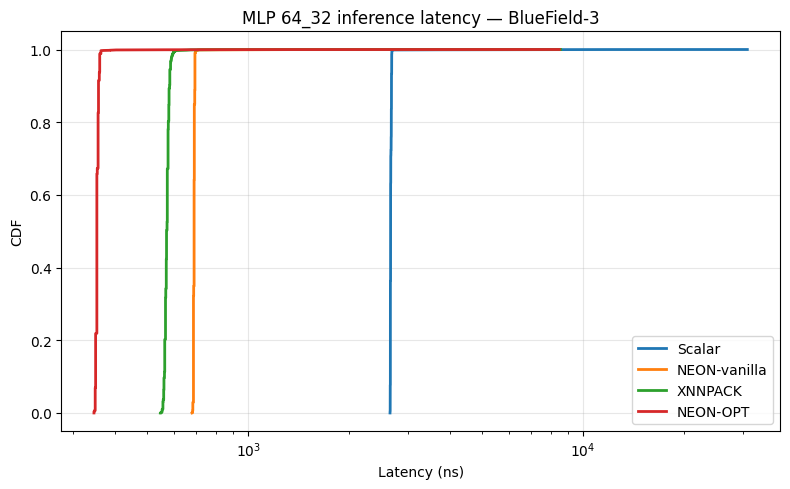

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "Scalar":  "../offline_bench/bf3/src/lat_scalar_64_32.csv",
    "NEON-vanilla":    "../offline_bench/bf3/src/lat_neon_64_32.csv",
    "XNNPACK": "../offline_bench/bf3/src/lat_xnn_64_32.csv",
    "NEON-OPT": "../offline_bench/bf3/src/lat_neon_opt_64_32.csv",
}
fig, ax = plt.subplots(figsize=(8, 5))

for label, path in files.items():
    df = pd.read_csv(path)
    lat = np.sort(df["latency_ns"].values)
    cdf = np.arange(1, len(lat) + 1) / len(lat)
    ax.plot(lat, cdf, label=label, linewidth=2)

ax.set_xlabel("Latency (ns)")
ax.set_ylabel("CDF")
ax.set_title("MLP 64_32 inference latency — BlueField-3")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/latency_cdf_64_32.png", dpi=150)
print("saved")

for label, path in files.items():
    df = pd.read_csv(path)
    lat = df["latency_ns"].values
    print(f"{label:10s} median={np.median(lat):8.1f} ns  p95={np.percentile(lat,95):8.1f} ns  p99={np.percentile(lat,99):8.1f} ns")